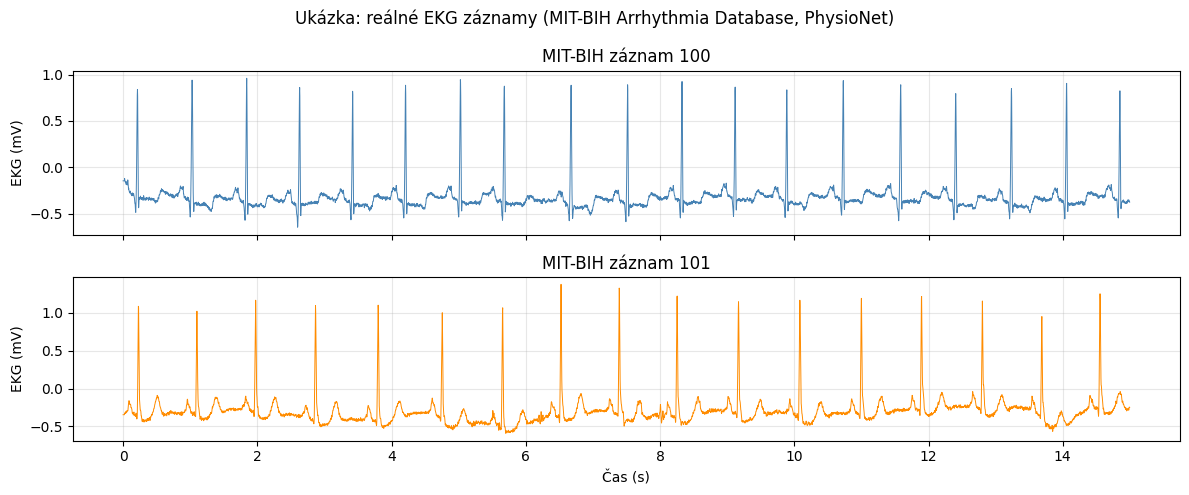

Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


In [11]:
# Ukázkové načtení a zobrazení dvou reálných EKG záznamů pomocí pevně zadané cesty
# Data z MIT-BIH Arrhythmia Database (PhysioNet), fs = 360 Hz
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

data_0 = np.loadtxt("ekg_real/mitbih_100.txt", skiprows=1)
data_1 = np.loadtxt("ekg_real/mitbih_101.txt", skiprows=1)
t0, ekg0 = data_0[:, 0], data_0[:, 1]
t1, ekg1 = data_1[:, 0], data_1[:, 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t0, ekg0, linewidth=0.7, color="steelblue")
ax1.set_ylabel("EKG (mV)")
ax1.set_title("MIT-BIH záznam 100")
ax1.grid(True, alpha=0.3)
ax2.plot(t1, ekg1, linewidth=0.7, color="darkorange")
ax2.set_xlabel("Čas (s)")
ax2.set_ylabel("EKG (mV)")
ax2.set_title("MIT-BIH záznam 101")
ax2.grid(True, alpha=0.3)
plt.suptitle("Ukázka: reálné EKG záznamy (MIT-BIH Arrhythmia Database, PhysioNet)")
plt.tight_layout()
plt.show()
print(f"Délka záznamu: {t0[-1]:.1f} s, vzorkovací frekvence: {1/(t0[1]-t0[0]):.0f} Hz")

Načteno 5400 klidových a 5400 zátěžových záznamů
Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


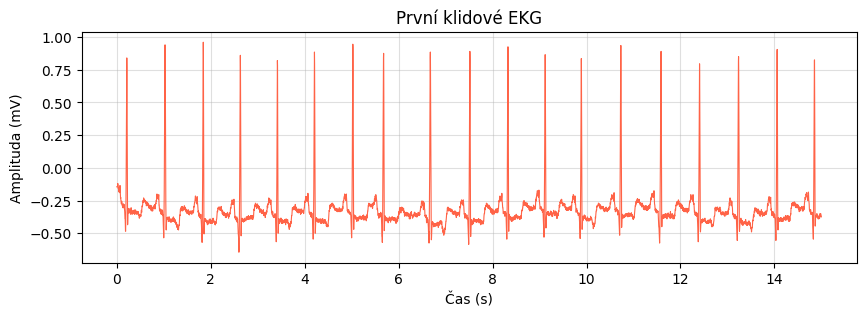

In [7]:
%matplotlib inline
import glob
import numpy as np
import matplotlib.pyplot as plt

#1. Seznamy souborů
klid = glob.glob("ekg_klid/*.txt")
zatez = glob.glob("ekg_zatez/*.txt")

#2. Klidový záznam a rozbalené t, ekg
data0 = np.loadtxt(klid[0], skiprows=1)
t = data0[:, 0]
ekg = data0[:, 1]

print(f"Načteno {len(data0)} klidových a {len(data0)} zátěžových záznamů")
print(f"Délka záznamu: {t[-1]:.1f} s, vzorkovací frekvence: {1/(t[1] - t[0]):.0f} Hz")

#3. Vykresli signál jako spojnicový graf s popsanými osami
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, ekg, linewidth=0.8, color="tomato")
ax.set_title("První klidové EKG")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Amplituda (mV)")
ax.grid(True, alpha=0.4)
plt.show()


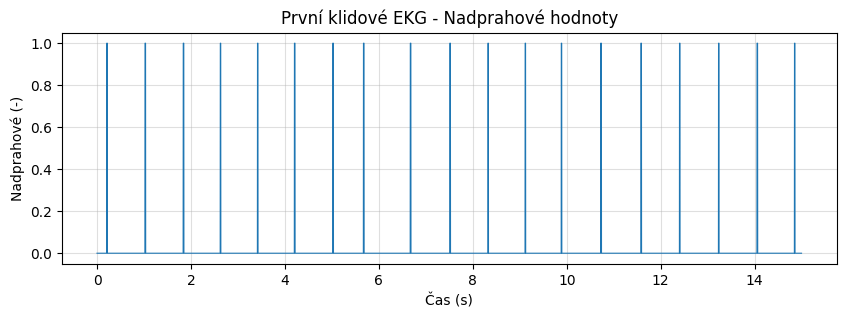

In [6]:
PRAH = 0.5 #mV
#1. Vytvoř logickou masku "ekg nad prahem"
nad_prahem = ekg > PRAH

#2. Vykresli binární signál nad_prahem v čase
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, nad_prahem, linewidth = 0.8)
ax.set_title("První klidové EKG - Nadprahové hodnoty")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Nadprahové (-)")
ax.grid(True, alpha=0.4)
plt.show()

Nalezeno vrcholů: 19


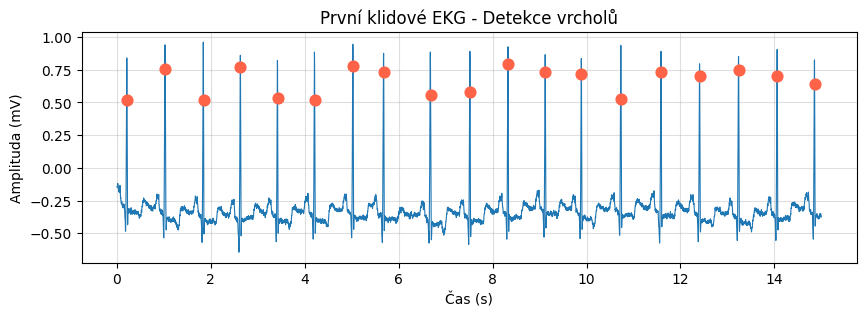

In [9]:
#1. Detekce R-Vrcholů
vrcholy_idx = np.where(np.diff(nad_prahem.astype(int)) == -1)[0]
print(f"Nalezeno vrcholů: {len(vrcholy_idx)}")

#2. Vykresli signál + značky (scatter) na pozicích t[vrcholy_idx], ekg[vrcholy_idx]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, ekg, linewidth=0.8)
ax.scatter(t[vrcholy_idx], ekg[vrcholy_idx], color="tomato", s=60, zorder=5)
ax.set_title("První klidové EKG - Detekce vrcholů")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Amplituda (mV)")
ax.grid(True, alpha=0.4)
plt.show()

In [10]:
cas_vrcholu = t[vrcholy_idx]
rr_intervaly = np.diff(cas_vrcholu)
tf_bpm = 60 // np.mean(rr_intervaly)

print(f"Průměrný R-R interval: {rr_intervaly.mean():.3f} s")
print(f"Tepová frekvence: {tf_bpm:.1f} BPM")

Průměrný R-R interval: 0.813 s
Tepová frekvence: 73.0 BPM


In [13]:
def spocitej(soubor):
    #1. Seznamy souborů
    klid = glob.glob("ekg_klid/*.txt")
    zatez = glob.glob("ekg_zatez/*.txt")

    #2. Klidový záznam a rozbalené t, ekg
    data0 = np.loadtxt(soubor, skiprows=1)
    t = data0[:, 0]
    ekg = data0[:, 1]
    PRAH = 0.5 #mV

    #3. Vytvoř logickou masku "ekg nad prahem"
    nad_prahem = ekg > PRAH

    #4. Detekce R-Vrcholů
    vrcholy_idx = np.where(np.diff(nad_prahem.astype(int)) == -1)[0]
    cas_vrcholu = t[vrcholy_idx]
    rr_intervaly = np.diff(cas_vrcholu)
    tf_bpm = 60 // np.mean(rr_intervaly)
    return tf_bpm

tf_klid = []
for soubor in klid:
    tf = spocitej(soubor)
    tf_klid.append(tf)
tf_zatez = []
for soubor in zatez:
    tf = spocitej(soubor)
    tf_zatez.append(tf)
tf_klid = np.array(tf_klid)
tf_zatez = np.array(tf_zatez)

print(tf_klid)
print(tf_zatez)

[73. 66. 62. 65. 67. 62. 67.]
[ 65.  97. 102. 107.  94. 100.]


Interpretace
Krátce komentuj:

Jak se klidová a zátěžová skupina liší v průměrné tepové frekvenci?
. Zátěžová skupina byla vyšší než klidová

Objevil se outlier?
. Ne, neobjevil

Odkud by mohl pocházet (reálná arytmie, šum, špatně zvolený práh)?
Proč je taková jednoduchá detekce (pevný práh + sestupná hrana) v praxi omezená? Co by bylo potřeba udělat pro robustnější detekci R-vrcholů (filtrace pásmovou propustí, adaptivní práh, Pan–Tompkinsův algoritmus)?
.